# 3 Demand prediction

### Split dataset

In [1]:
import pandas as pd
from scripts.constants import *



daily_agg = pd.read_csv('data/daily_aggregated_data.csv', parse_dates=['stay_date'])
daily_agg = daily_agg.set_index('stay_date').sort_index()
daily_frequency = daily_agg['room_nights'].asfreq('D')

train_series = daily_frequency[:-PREDICTION_HORIZON_DAYS]
test_series = daily_frequency[-PREDICTION_HORIZON_DAYS:]

## SARIMA

### Fit auto_arima

In [3]:
from pmdarima import auto_arima

models=[]

test_range = range(1,2,1)

for i in test_range:
    models.append(
         auto_arima(
        train_series,
        seasonal=True,
        m=i, # number of days in seasonality
        stepwise=True,
        suppress_warnings=True,
        trace=True
        )
    )
    print(f"Completed model with m={i}")

print(models[-1].summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=3363.167, Time=0.37 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3582.378, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=3577.122, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=3575.282, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3580.385, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=3463.775, Time=0.14 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=3433.866, Time=0.11 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=3343.372, Time=0.35 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=3398.227, Time=0.11 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=3401.191, Time=0.42 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=3351.528, Time=0.44 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=3333.011, Time=0.37 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=3422.384, Time=0.19 sec
 ARIMA(2,1,4)(0,0,0)[0] intercept   : AIC=3317.283, Time=0.47 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept

### Demand Prediction

In [4]:
forecasts_sarima = [model.predict(n_periods=PREDICTION_HORIZON_DAYS) for model in models]

## Transformer

### Train model

In [4]:
# from darts import TimeSeries
# from darts.models import TransformerModel

# series = TimeSeries.from_series(train_series)

# model = TransformerModel(
#     input_chunk_length=len(train_series)//3,
#     output_chunk_length=PREDICTION_HORIZON_DAYS,
#     n_epochs=150,
#     random_state=42,
#     batch_size=21,
# )

# model.fit(series)

### Prediction

In [5]:

# forecast_transformer = model.predict(n=PREDICTION_HORIZON_DAYS)

## Evaluation

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pandas import DataFrame

sarima_eval_df = DataFrame(
    {
        'm': list(test_range),
        'MAE': [mean_absolute_error(test_series, forecast) for forecast in forecasts_sarima],
        'RMSE': [mean_squared_error(test_series, forecast, squared=False) for forecast in forecasts_sarima]
    }
)

best_sarima_index = sarima_eval_df['MAE'].idxmin()
print(f"Best SARIMA model index: {best_sarima_index}")
forecast_sarima = forecasts_sarima[best_sarima_index]

print(models[best_sarima_index].summary())

# save best prediction series into csv
pd.DataFrame({
    'SARIMA_Forecast': forecast_sarima,
    # 'Transformer_Forecast': forecast_transformer.values().flatten(),
    'Actual': test_series.values
}, index=test_series.index).to_csv('data/demand_forecasts.csv')

Best SARIMA model index: 0
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  546
Model:               SARIMAX(2, 1, 4)   Log Likelihood               -1650.642
Date:                Sun, 05 Apr 2026   AIC                           3317.283
Time:                        16:03:22   BIC                           3351.690
Sample:                    11-03-2023   HQIC                          3330.734
                         - 05-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0045      0.084     -0.054      0.957      -0.169       0.160
ar.L1          1.2452      0.004    313.298      0.000       1.237       1.253
ar.L2         -0.9967    

In [6]:
sarima_eval = { 
    'MAE': mean_absolute_error(test_series, forecast_sarima),
    'RMSE': mean_squared_error(test_series, forecast_sarima, squared=False)
}
print(sarima_eval)

# transformer_eval = {
#     'MAE': mean_absolute_error(test_series, forecast_transformer.values().flatten()),
#     'RMSE': mean_squared_error(test_series, forecast_transformer.values().flatten(), squared=False)
# }
# print(transformer_eval)

{'MAE': 4.508611002303967, 'RMSE': 5.458011360387385}


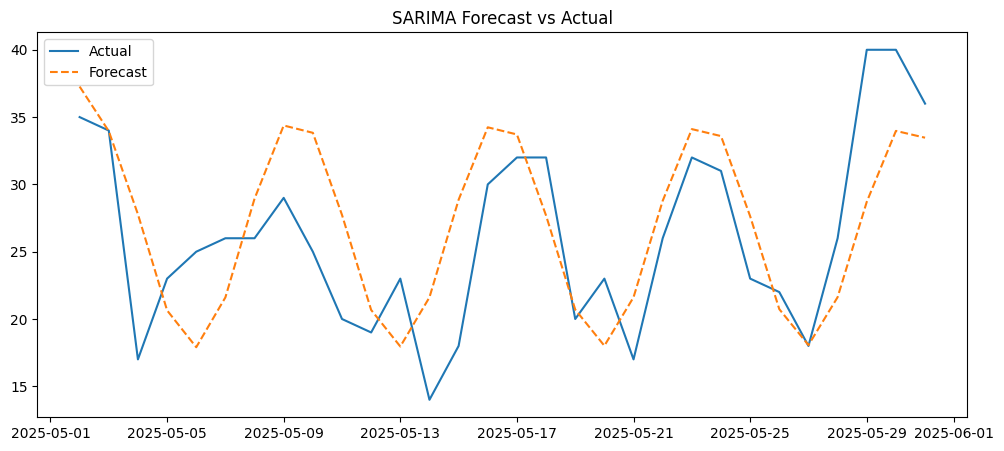

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(test_series.index, test_series, label='Actual')
plt.plot(forecast_sarima.index, forecast_sarima, label='Forecast', linestyle='--')
# plt.plot(forecast_transformer.index, forecast_transformer.values().flatten(), label='Forecast', linestyle=':')
plt.legend()
plt.title('SARIMA Forecast vs Actual')
plt.show()